In [39]:
import pandas as pd

df = pd.read_csv("data/transactions.csv")
df.head()

,transaction_id,amount,hour,day_of_week,merchant_category,customer_age,device_anomaly,velocity_anomaly,is_fraud
0,1,102.24,2,3,online,37,0.456,0.185,0
1,2,29.31,18,3,dining,60,-0.872,-0.621,0
2,3,3.53,15,0,grocery,63,-0.799,0.681,0
3,4,3717.13,10,0,grocery,41,1.013,1.355,0
4,5,7.53,10,4,travel,73,-0.553,-1.679,0


In [40]:
print("Total transactions:", len(df))
print("Fraud cases:", df["is_fraud"].sum())
print("Fraud rate:", round(df["is_fraud"].mean() * 100, 2), "%")

Total transactions: 12000
Fraud cases: 561
Fraud rate: 4.68 %


In [41]:
df["is_night"] = ((df["hour"] < 6) | (df["hour"] >= 23)).astype(int)
(df.groupby("is_night")["is_fraud"].mean() * 100).round(2)

is_night
0    2.99
1    8.71
Name: is_fraud, dtype: float64

In [42]:
(df.groupby("merchant_category")["is_fraud"].mean() * 100).round(2).sort_values(ascending=False)

merchant_category
electronics    9.23
online         5.88
utilities      4.29
dining         3.81
travel         3.16
grocery        3.14
Name: is_fraud, dtype: float64

In [43]:
print(df.groupby("is_fraud")["amount"].mean().round(2))
print(df.groupby("is_fraud")[["device_anomaly", "velocity_anomaly"]].mean().round(2))

is_fraud
0    512.71
1    829.62
Name: amount, dtype: float64
          device_anomaly  velocity_anomaly
is_fraud                                  
0                  -0.04             -0.04
1                   0.53              0.48


In [44]:
print("Accuracy of a 'predict all legit' model:", round((1 - df["is_fraud"].mean()) * 100, 1), "%")

Accuracy of a 'predict all legit' model: 95.3 %


In [45]:
# Always check data quality first
print("Missing values:", df.isnull().sum().sum())

# Recreate the night flag (fraud is ~3x more likely at night) in case it's not there
df["is_night"] = ((df["hour"] < 6) | (df["hour"] >= 23)).astype(int)

Missing values: 0


In [46]:
# y = what we predict (fraud or not); X = everything we predict FROM
y = df["is_fraud"]

# Drop the target and the ID (an ID has no predictive meaning)
X = df.drop(columns=["is_fraud", "transaction_id"])

In [47]:
# Models need numbers, so one-hot encode the merchant category
X = pd.get_dummies(X, columns=["merchant_category"], drop_first=True)
print("Number of feature columns:", X.shape[1])

Number of feature columns: 12


In [48]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the SAME fraud rate (~4.7%) in both train and test sets —
# essential with rare events, so the test set actually contains enough fraud to measure
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train fraud rate:", round(y_train.mean() * 100, 2), "%")
print("Test fraud rate:", round(y_test.mean() * 100, 2), "%")

Train fraud rate: 4.68 %
Test fraud rate: 4.67 %


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, precision_score

# A standard model that IGNORES the imbalance
naive = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
naive.fit(X_train, y_train)

pred_naive = naive.predict(X_test)
print("Naive model — fraud recall:", round(recall_score(y_test, pred_naive) * 100, 1), "%")

Naive model — fraud recall: 0.9 %


In [50]:
# class_weight="balanced" makes each rare fraud case count MUCH more during training,
# forcing the model to actually pay attention to the minority class
balanced = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
balanced.fit(X_train, y_train)

pred = balanced.predict(X_test)
print("Balanced model — fraud recall:", round(recall_score(y_test, pred) * 100, 1), "%")
print("Balanced model — fraud precision:", round(precision_score(y_test, pred) * 100, 1), "%")

Balanced model — fraud recall: 71.4 %
Balanced model — fraud precision: 10.9 %


In [51]:
from sklearn.metrics import confusion_matrix, classification_report

# Get fraud probabilities, then flag as fraud if probability >= 0.5
proba = balanced.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Confusion matrix [rows = actual, cols = predicted]:")
print(confusion_matrix(y_test, pred))

Confusion matrix [rows = actual, cols = predicted]:
[[1632  656]
 [  32   80]]


In [52]:
from sklearn.metrics import average_precision_score

print(classification_report(y_test, pred, target_names=["Legit", "Fraud"]))

# PR-AUC is the RIGHT summary score for rare events (ROC-AUC flatters imbalanced data)
print("PR-AUC:", round(average_precision_score(y_test, proba), 3))

              precision    recall  f1-score   support

       Legit       0.98      0.71      0.83      2288
       Fraud       0.11      0.71      0.19       112

    accuracy                           0.71      2400
   macro avg       0.54      0.71      0.51      2400
weighted avg       0.94      0.71      0.80      2400

PR-AUC: 0.216


In [53]:
# Lower threshold = catch more fraud, but more false alarms. This is a BUSINESS choice.
for t in [0.5, 0.3]:
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    print(f"Threshold {t}: caught {tp}/{tp+fn} frauds, {fp} false alarms")

Threshold 0.5: caught 80/112 frauds, 656 false alarms
Threshold 0.3: caught 98/112 frauds, 1291 false alarms


In [54]:
import numpy as np

# Pull the first significant digit from each transaction amount
def first_digit(x):
    s = str(abs(x)).replace(".", "").lstrip("0")
    return int(s[0]) if s else 0

df["first_digit"] = df["amount"].apply(first_digit)

# Benford's Law: the expected % for each leading digit 1-9
benford = {d: np.log10(1 + 1/d) * 100 for d in range(1, 10)}

In [55]:
def digit_dist(subset):
    counts = subset["first_digit"].value_counts(normalize=True).sort_index() * 100
    return [counts.get(d, 0) for d in range(1, 10)]

legit_dist = digit_dist(df[df["is_fraud"] == 0])
fraud_dist = digit_dist(df[df["is_fraud"] == 1])
benford_dist = [benford[d] for d in range(1, 10)]

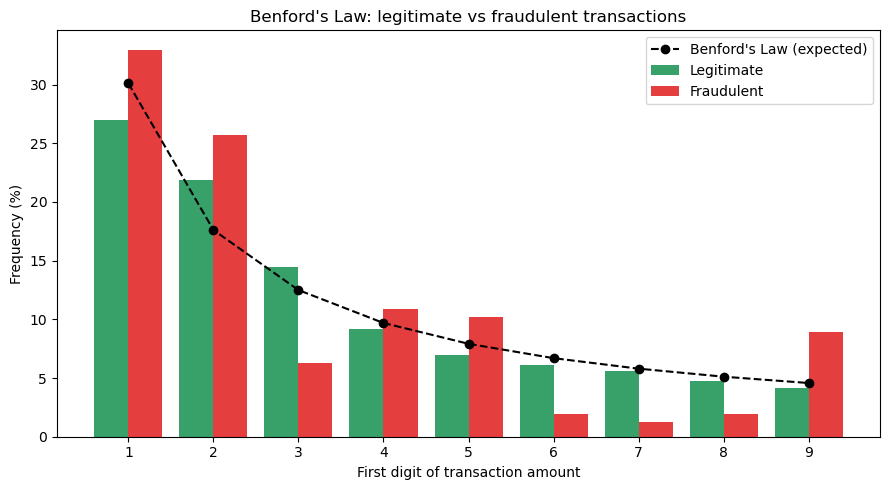

In [56]:
import matplotlib.pyplot as plt

digits = range(1, 10)
plt.figure(figsize=(9, 5))
plt.plot(digits, benford_dist, "k--o", label="Benford's Law (expected)")
plt.bar([d - 0.2 for d in digits], legit_dist, width=0.4, label="Legitimate", color="#38a169")
plt.bar([d + 0.2 for d in digits], fraud_dist, width=0.4, label="Fraudulent", color="#e53e3e")
plt.xlabel("First digit of transaction amount"); plt.ylabel("Frequency (%)")
plt.title("Benford's Law: legitimate vs fraudulent transactions")
plt.xticks(list(digits)); plt.legend()
plt.tight_layout(); plt.savefig("benford_analysis.png", dpi=150); plt.show()

# FinTech Fraud Detection — Executive Summary

## The problem
Fraud accounts for ~4.7% of transactions but causes losses far larger than its
frequency suggests. A detection model must catch as much fraud as possible without
overwhelming the review team with false alarms.

## What I did
Built and evaluated a fraud-detection model on ~12,000 transactions, then applied a
Benford's Law forensic check to independently test the amounts for manipulation.

## Key results
- **Fraud is predictable.** It is ~3x more likely at night and concentrated in
  electronics and online purchases, with higher amounts and behavioural-anomaly scores.
- **Handling class imbalance is essential.** A naive model caught just ~1% of fraud;
  weighting the model to prioritise the rare fraud class raised that to **~71%**.
- **Detection is a business trade-off.** At the chosen threshold the model catches
  ~71% of fraud while flagging ~30% of transactions for review. Lowering the
  threshold catches even more fraud at the cost of more false alarms.
- **Benford's Law flags manipulation.** Legitimate amounts follow the expected
  digit distribution; fraudulent amounts clearly deviate — an independent red flag.

## Recommendation
1. **Deploy the model as a first-pass filter** that routes high-risk transactions to
   human review, rather than auto-blocking, to protect genuine customers.
2. **Set the threshold from real costs** — the average loss per missed fraud vs the
   cost of a review — rather than a default of 0.5.
3. **Add Benford's Law monitoring** to the audit process as a second, independent
   line of defence against manipulated figures.
4. **Prioritise night-time, high-value, electronics/online transactions** for tighter
   controls, where fraud risk is highest.

## What I'd do next
Test stronger models (Random Forest, gradient boosting), try SMOTE for the imbalance,
and validate the threshold against real per-transaction cost data.